<a href="https://colab.research.google.com/github/Blecyrajan/Dissertation/blob/main/BrainTumor_CNN_ViT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Downloading dataset




In [6]:
import kagglehub
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.


# 2. Install required libraries

In [7]:
!pip install torch torchvision opencv-python matplotlib tqdm scikit-learn

## 3. Import required libraries

In [8]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


# 3. Dataset path






In [9]:
DATASET_PATH = "/kaggle/input/brain-tumor-mri-dataset"

In [10]:
os.listdir(DATASET_PATH)

['Training', 'Testing']

In [11]:
TRAIN_PATH = os.path.join(DATASET_PATH, "Training")
TEST_PATH  = os.path.join(DATASET_PATH, "Testing")

print("Train folders:", os.listdir(TRAIN_PATH))
print("Test folders:", os.listdir(TEST_PATH))

Train folders: ['pituitary', 'notumor', 'meningioma', 'glioma']
Test folders: ['pituitary', 'notumor', 'meningioma', 'glioma']


In [13]:
print("Dataset root:", os.listdir(DATASET_PATH))
print("\nTraining classes:", os.listdir(os.path.join(DATASET_PATH, "Training")))
print("\nTesting classes:", os.listdir(os.path.join(DATASET_PATH, "Testing")))


Dataset root: ['Training', 'Testing']

Training classes: ['pituitary', 'notumor', 'meningioma', 'glioma']

Testing classes: ['pituitary', 'notumor', 'meningioma', 'glioma']


# 4. Sample brain MRI

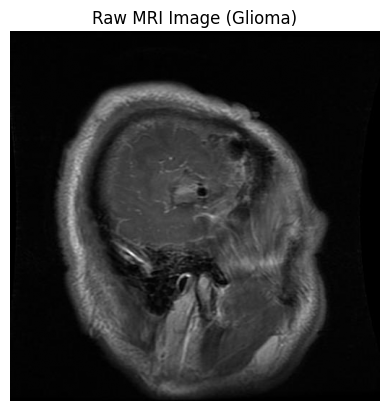

In [14]:
sample_class = "glioma"
sample_image = os.listdir(os.path.join(TRAIN_PATH, sample_class))[0]

img_path = os.path.join(TRAIN_PATH, sample_class, sample_image)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title("Raw MRI Image (Glioma)")
plt.axis("off")
plt.show()


# 5. Preprocessing

In [15]:
IMG_SIZE = 224

def preprocess_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) #resize to 224 x 224
    img = img / 255.0 #pixels are normalized

    # convert grayscale → 3 channel
    img = np.stack([img, img, img], axis=-1)

    return img


# 6. After preprocessing

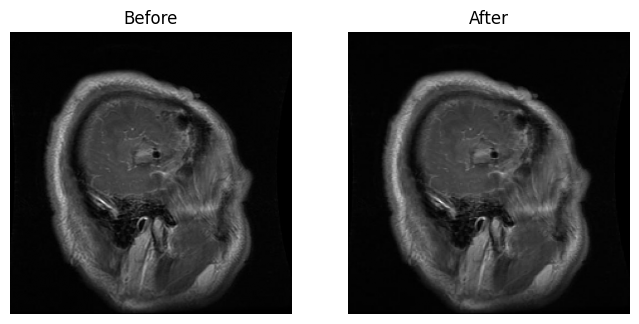

In [16]:
processed = preprocess_image(img_path)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Before")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("After")
plt.imshow(processed[:,:,0], cmap="gray")
plt.axis("off")

plt.show()


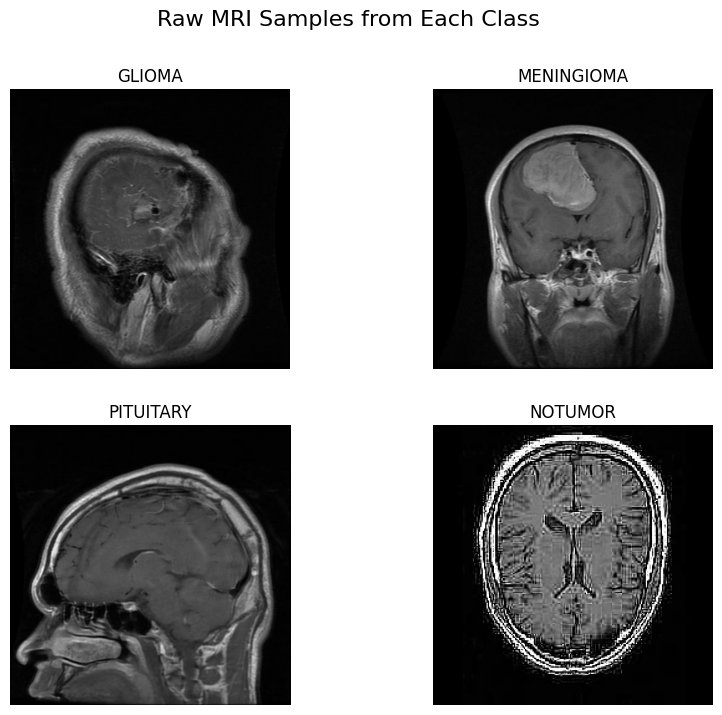

In [17]:
classes = ["glioma", "meningioma", "pituitary", "notumor"]

plt.figure(figsize=(10,8))

for i, cls in enumerate(classes):
    img_name = os.listdir(os.path.join(TRAIN_PATH, cls))[0]
    img_path = os.path.join(TRAIN_PATH, cls, img_name)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    plt.subplot(2,2,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(cls.upper())
    plt.axis("off")

plt.suptitle("Raw MRI Samples from Each Class", fontsize=16)
plt.show()


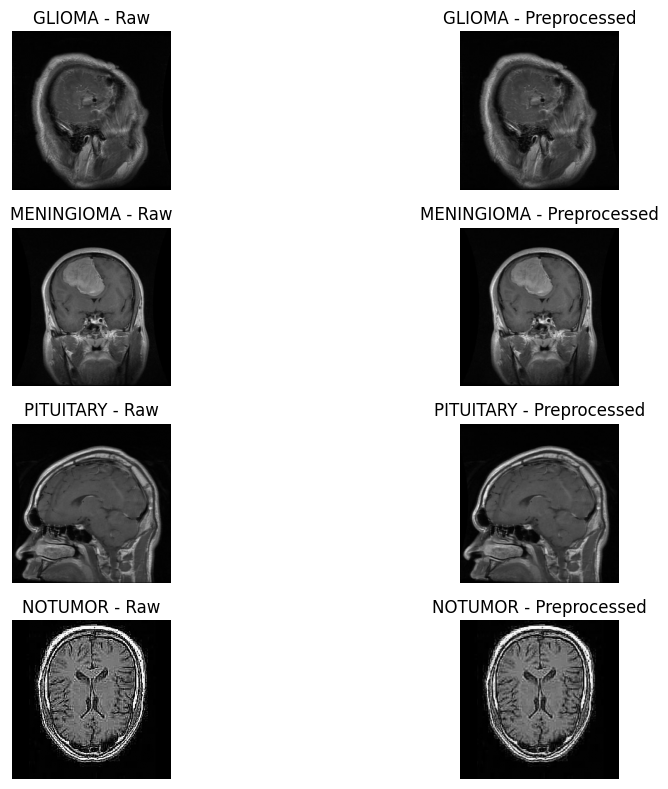

In [18]:
plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):
    img_name = os.listdir(os.path.join(TRAIN_PATH, cls))[0]
    img_path = os.path.join(TRAIN_PATH, cls, img_name)

    raw = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    processed = preprocess_image(img_path)

    # Raw
    plt.subplot(4,2,2*i+1)
    plt.imshow(raw, cmap="gray")
    plt.title(f"{cls.upper()} - Raw")
    plt.axis("off")

    # Processed
    plt.subplot(4,2,2*i+2)
    plt.imshow(processed[:,:,0], cmap="gray")
    plt.title(f"{cls.upper()} - Preprocessed")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [19]:
print("Raw image stats:")
print("Min:", raw.min(), "Max:", raw.max())

print("\nPreprocessed image stats:")
print("Min:", processed.min(), "Max:", processed.max())


Raw image stats:
Min: 0 Max: 255

Preprocessed image stats:
Min: 0.0 Max: 1.0
